<a href="https://colab.research.google.com/github/PraveenKumar-pk-star/DS-corrected-file/blob/main/Forecasting_of_GoldPrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('Gold_data.csv')

In [ ]:
df.head()

,date,price
0,2016-01-01,2252.60
1,2016-01-02,2454.50
2,2016-01-03,2708.10
3,2016-01-04,2577.80
4,2016-01-05,2597.75


In [ ]:
df.columns = ['date', 'price']

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

In [ ]:
# Summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2182 entries, 2016-01-01 to 2021-12-21
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   2182 non-null   float64
dtypes: float64(1)
memory usage: 34.1 KB


In [ ]:
# Check for missing values
df.isnull().sum()

,0
price,0


In [ ]:
# Descriptive statistics
df.describe()

,price
count,2182.000000
mean,3284.450046
std,719.564434
min,2252.600000
25%,2697.020000
50%,2879.800000
75%,4147.325000
max,4966.300000


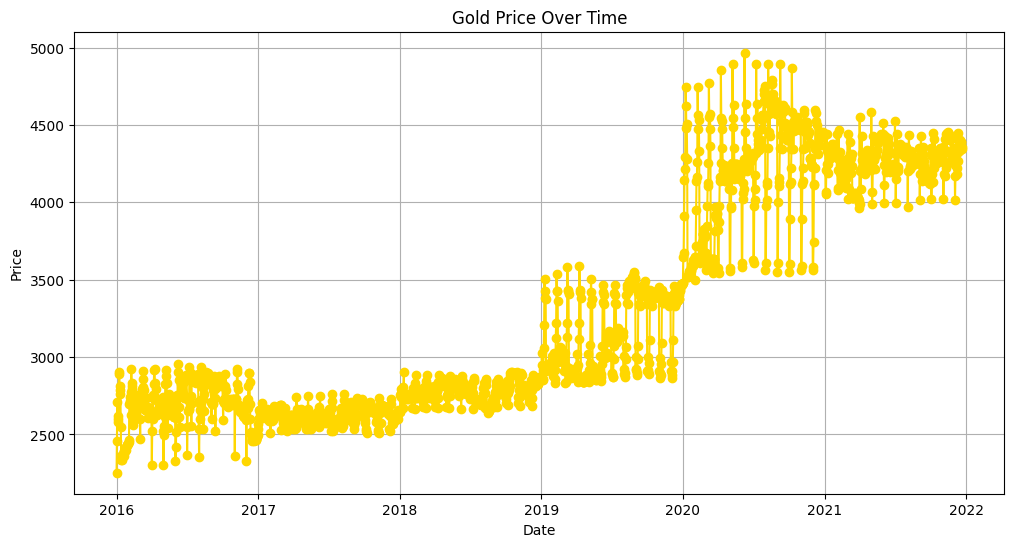

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['price'], marker='o', linestyle='-', color='gold')
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

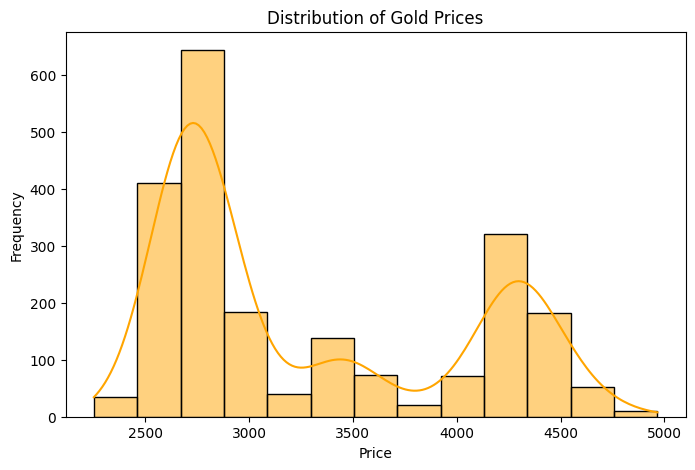

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, color='orange')
plt.title('Distribution of Gold Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Daily price change
df['price_change'] = df['price'].diff()

# Daily return (percentage change)
df['price_return'] = df['price'].pct_change() * 100

df[['price', 'price_change', 'price_return']].head()


,price,price_change,price_return
date,,,
2016-01-01,2252.60,NaN,NaN
2016-01-02,2454.50,201.90,8.962976
2016-01-03,2708.10,253.60,10.332043
2016-01-04,2577.80,-130.30,-4.811491
2016-01-05,2597.75,19.95,0.773916


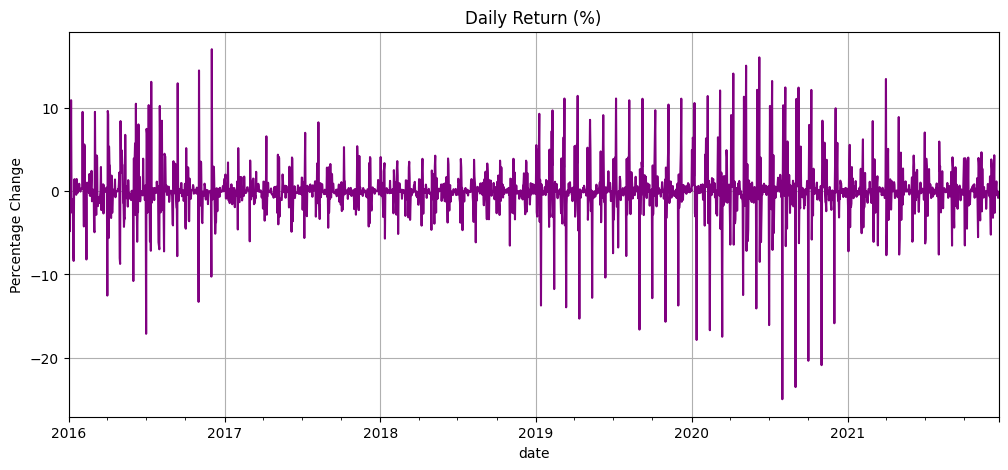

In [ ]:
plt.figure(figsize=(12,5))
df['price_return'].plot(color='purple')
plt.title('Daily Return (%)')
plt.ylabel('Percentage Change')
plt.grid(True)
plt.show()


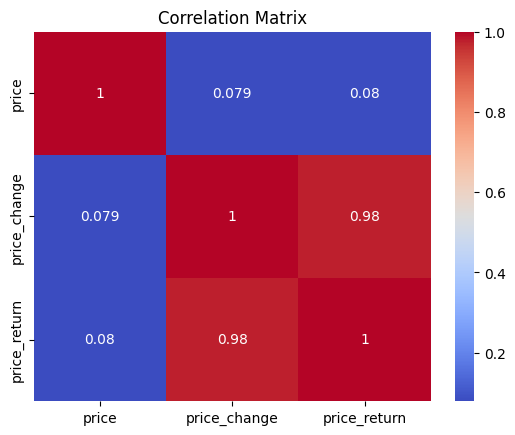

In [ ]:
# For now it's only 'price', 'price_change', 'price_return'
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

<ipython-input-13-880185ff1777>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['price'].resample('M').mean()


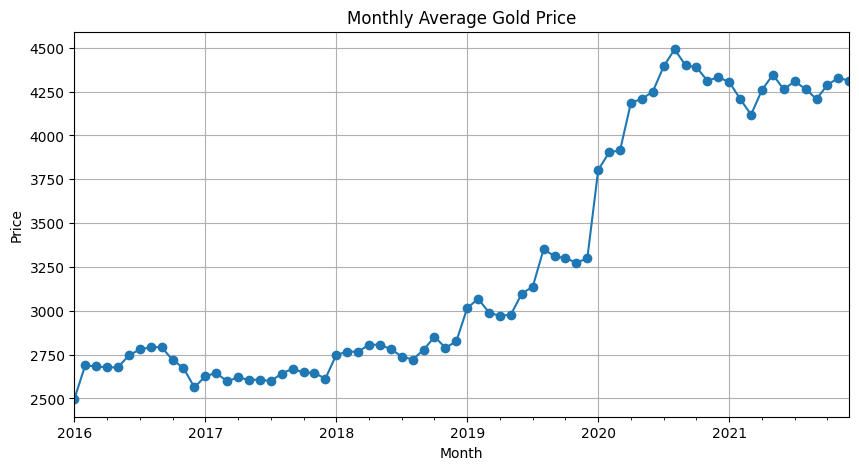

In [ ]:
monthly_avg = df['price'].resample('M').mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(marker='o')
plt.title('Monthly Average Gold Price')
plt.xlabel('Month')
plt.ylabel('Price')
plt.grid(True)
plt.show()

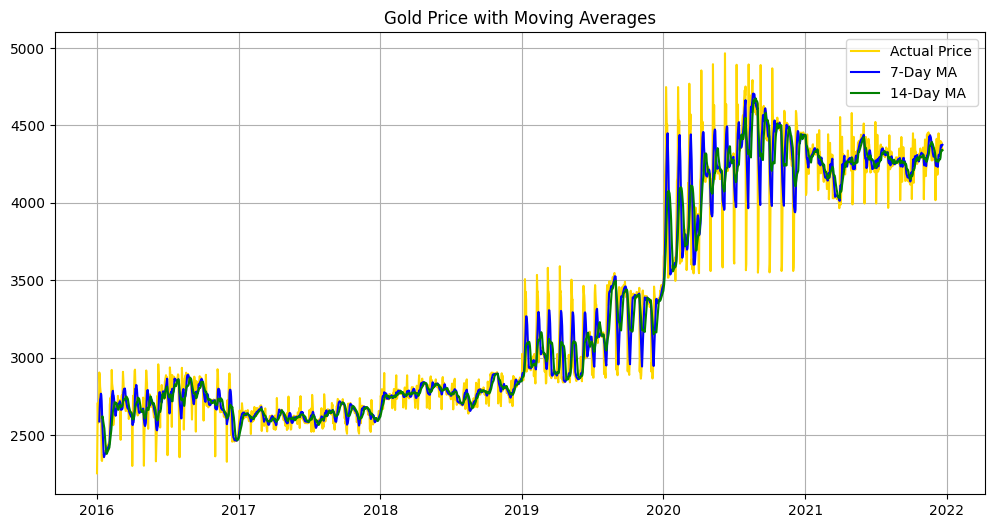

In [ ]:
df['MA7'] = df['price'].rolling(window=7).mean()
df['MA14'] = df['price'].rolling(window=14).mean()

plt.figure(figsize=(12,6))
plt.plot(df['price'], label='Actual Price', color='gold')
plt.plot(df['MA7'], label='7-Day MA', color='blue')
plt.plot(df['MA14'], label='14-Day MA', color='green')
plt.title('Gold Price with Moving Averages')
plt.legend()
plt.grid(True)
plt.show()

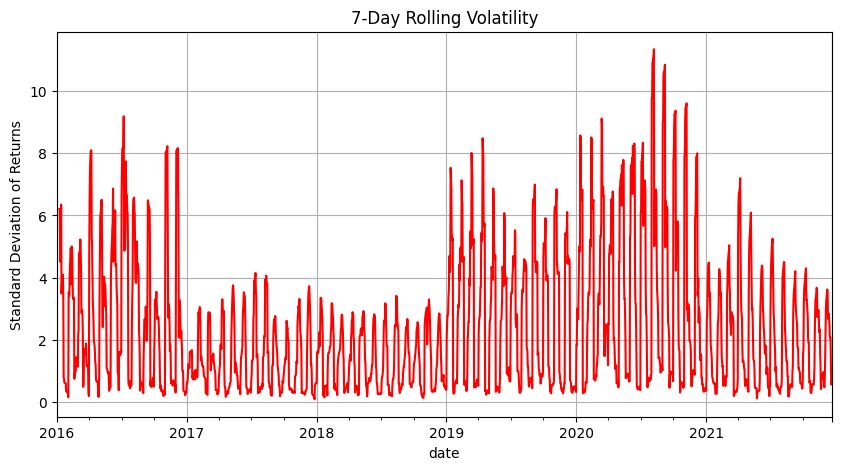

In [ ]:
df['volatility'] = df['price_return'].rolling(window=7).std()

plt.figure(figsize=(10,5))
df['volatility'].plot(color='red')
plt.title('7-Day Rolling Volatility')
plt.ylabel('Standard Deviation of Returns')
plt.grid(True)
plt.show()

<ipython-input-16-06067bf06464>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_change = df['price'].resample('M').last().diff()


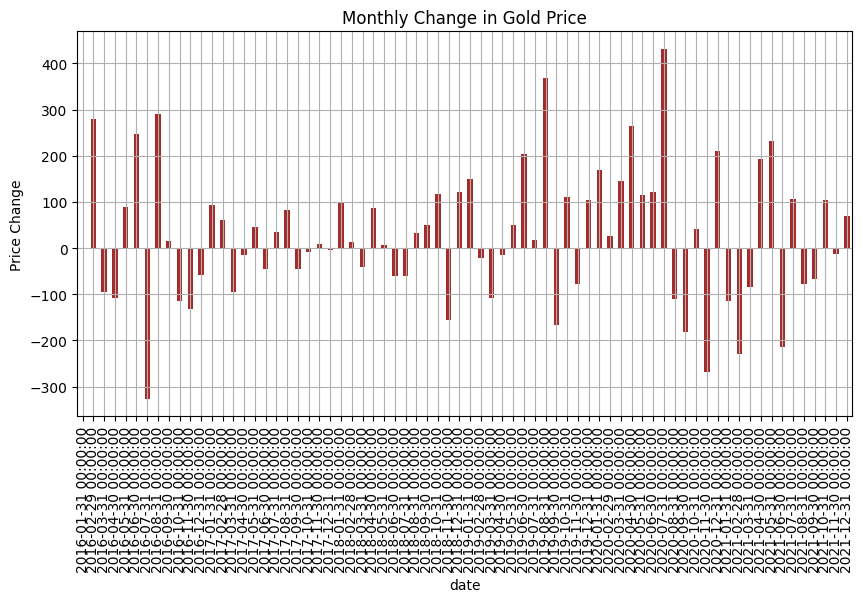

In [ ]:
monthly_change = df['price'].resample('M').last().diff()

plt.figure(figsize=(10,5))
monthly_change.plot(kind='bar', color='brown')
plt.title('Monthly Change in Gold Price')
plt.ylabel('Price Change')
plt.grid(True)
plt.show()

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['price'] < Q1 - 1.5 * IQR) | (df['price'] > Q3 + 1.5 * IQR)]
print(f"Number of outliers: {len(outliers)}")
outliers


Number of outliers: 0


,price,price_change,price_return,MA7,MA14,volatility
date,,,,,,


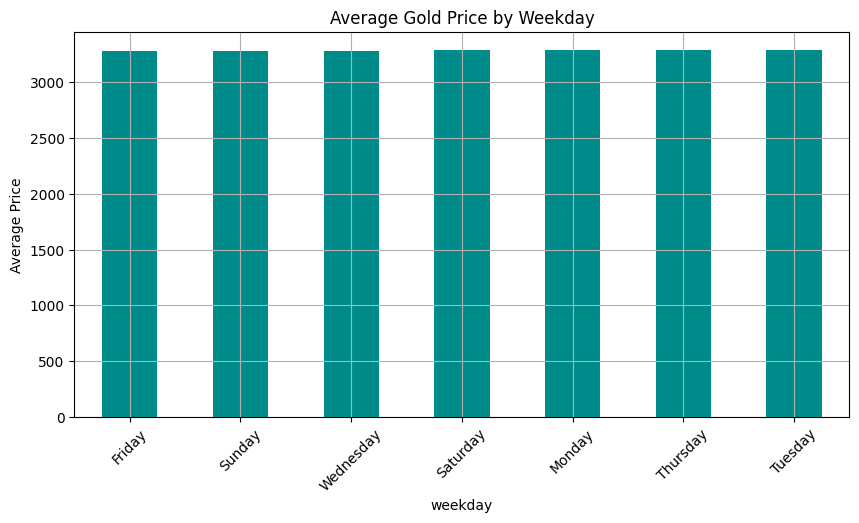

In [ ]:
df['weekday'] = df.index.day_name()

weekday_avg = df.groupby('weekday')['price'].mean().sort_values()

plt.figure(figsize=(10,5))
weekday_avg.plot(kind='bar', color='darkcyan')
plt.title('Average Gold Price by Weekday')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
df.tail()

,price,price_change,price_return,MA7,MA14,volatility,weekday
date,,,,,,,
2021-12-17,4394.4,-5.4,-0.122733,4372.128571,4319.957143,2.083990,Friday
2021-12-18,4389.5,-4.9,-0.111506,4363.642857,4335.607143,1.195446,Saturday
2021-12-19,4389.5,0.0,0.000000,4371.642857,4341.607143,0.554999,Sunday
2021-12-20,4354.1,-35.4,-0.806470,4372.028571,4337.357143,0.654021,Monday
2021-12-21,4346.5,-7.6,-0.174548,4374.642857,4339.292857,0.617337,Tuesday


In [ ]:
from sklearn.model_selection import train_test_split
test_ratio = 0.2
split_index = int(len(df) * (1 - test_ratio))

train = df['price'][:split_index]
test = df['price'][split_index:]

In [ ]:
from sklearn.linear_model import LinearRegression
x = np.arange(len(df)).reshape(-1, 1)
y=df["price"]
model=LinearRegression()
model.fit(x,y)

LinearRegression()

In [ ]:
future_x = np.arange(len(df), len(df) + 30).reshape(-1, 1)
future_preds = model.predict(future_x)


In [ ]:
future_preds

array([4384.63841654, 4385.64637657, 4386.6543366 , 4387.66229663,
       4388.67025666, 4389.67821668, 4390.68617671, 4391.69413674,
       4392.70209677, 4393.7100568 , 4394.71801682, 4395.72597685,
       4396.73393688, 4397.74189691, 4398.74985694, 4399.75781697,
       4400.76577699, 4401.77373702, 4402.78169705, 4403.78965708,
       4404.79761711, 4405.80557713, 4406.81353716, 4407.82149719,
       4408.82945722, 4409.83741725, 4410.84537727, 4411.8533373 ,
       4412.86129733, 4413.86925736])

In [ ]:
# Create future dates starting after the last date
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

# Create DataFrame for future predictions
future_df = pd.DataFrame({
    'date': future_dates,
    'predicted_price': future_preds
})

In [ ]:
future_dates

DatetimeIndex(['2021-12-22', '2021-12-23', '2021-12-24', '2021-12-25',
               '2021-12-26', '2021-12-27', '2021-12-28', '2021-12-29',
               '2021-12-30', '2021-12-31', '2022-01-01', '2022-01-02',
               '2022-01-03', '2022-01-04', '2022-01-05', '2022-01-06',
               '2022-01-07', '2022-01-08', '2022-01-09', '2022-01-10',
               '2022-01-11', '2022-01-12', '2022-01-13', '2022-01-14',
               '2022-01-15', '2022-01-16', '2022-01-17', '2022-01-18',
               '2022-01-19', '2022-01-20'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
future_df

,date,predicted_price
0,2021-12-22,4384.638417
1,2021-12-23,4385.646377
2,2021-12-24,4386.654337
3,2021-12-25,4387.662297
4,2021-12-26,4388.670257
5,2021-12-27,4389.678217
6,2021-12-28,4390.686177
7,2021-12-29,4391.694137
8,2021-12-30,4392.702097
9,2021-12-31,4393.710057


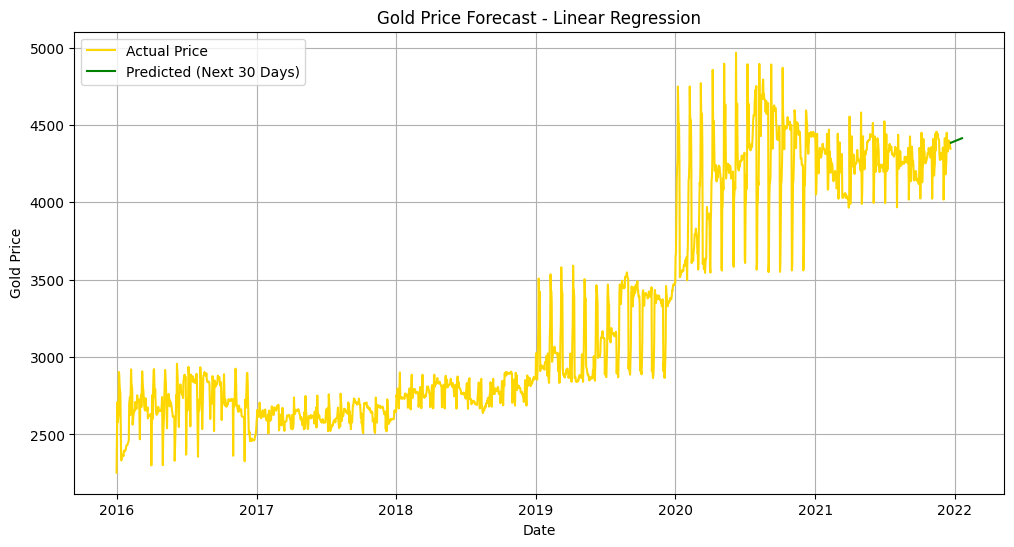

In [ ]:
plt.figure(figsize=(12, 6))

# Plot actual prices
plt.plot(df.index, df['price'], label='Actual Price', color='gold')

# Plot future predicted prices
plt.plot(future_df['date'], future_df['predicted_price'], label='Predicted (Next 30 Days)', color='green')

plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.title("Gold Price Forecast - Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(x)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 114433.85
R² Score: 0.78


In [ ]:
# ARIMA


In [ ]:
from statsmodels.tsa.arima.model import ARIMA


In [ ]:
model_arima=ARIMA(train,order=(1,1,1))
model_arima_fit=model_arima.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
forecast = model_arima_fit.forecast(steps=len(test))


In [ ]:
# last_date = train.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(test))
forecast_df = pd.DataFrame({'date': future_dates, 'forecast_price': forecast})
forecast_df.set_index('date', inplace=True)
forecast_df.tail()


,forecast_price
date,
2023-02-27,4535.241403
2023-02-28,4535.241403
2023-03-01,4535.241403
2023-03-02,4535.241403
2023-03-03,4535.241403


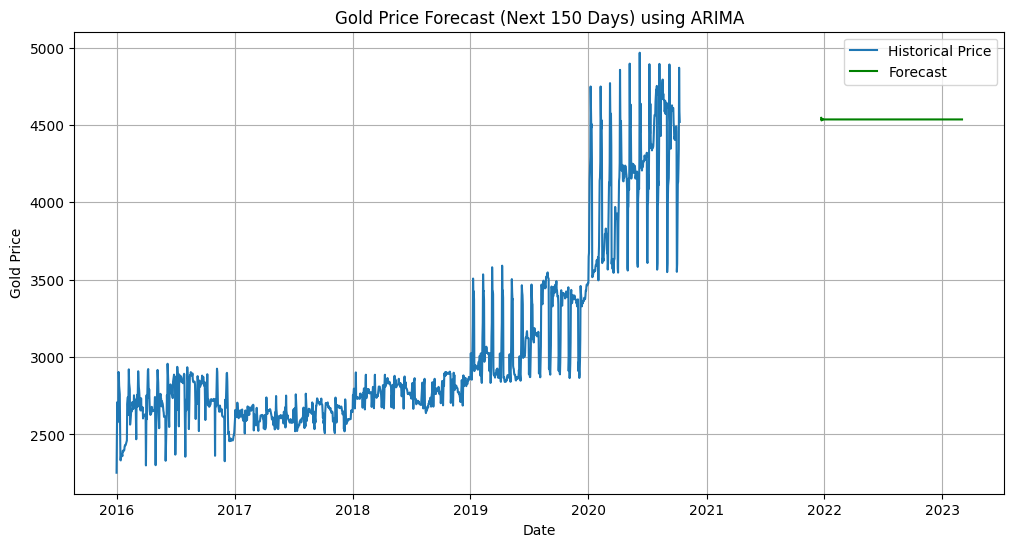

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train, label='Historical Price')
plt.plot(forecast_df, label='Forecast', color='green')
plt.title('Gold Price Forecast (Next 150 Days) using ARIMA')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
mse=mean_squared_error(test,forecast)
print(f"mean squared error:{mse}")


mean squared error:84399.08755877476


In [ ]:
rmse=np.sqrt(mse)
print(f"root mean squared error:{rmse}")

root mean squared error:290.51521054632366


Text(0.5, 1.0, 'AIRMA model price predcition')

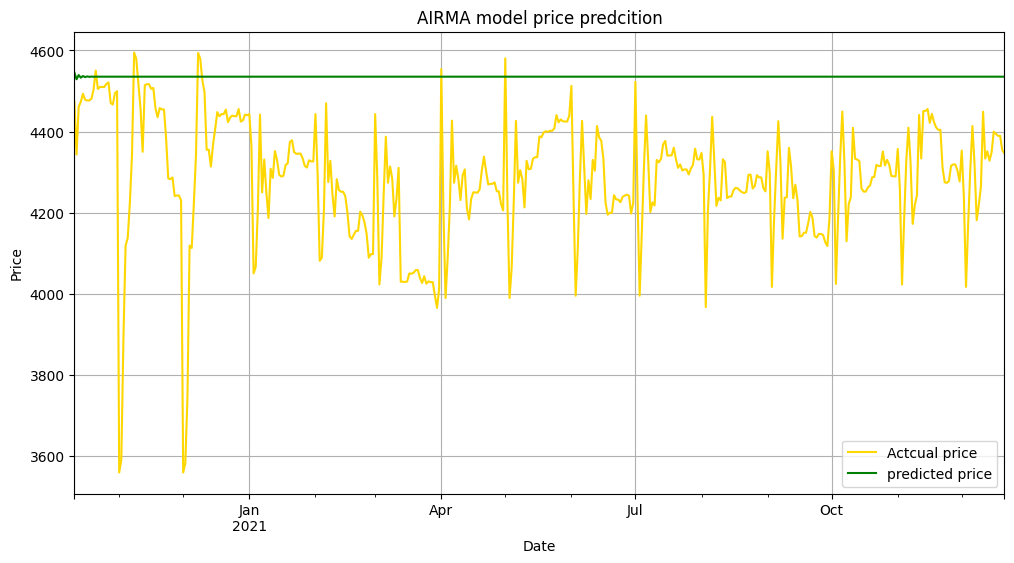

In [ ]:
plt.figure(figsize=(12, 6))
test.plot(label="Actcual price",color="gold")
forecast.plot(label="predicted price",color="green")
plt.legend()
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("AIRMA model price predcition")


In [ ]:
error_percentage=(rmse/df['price'].mean())*100
print(f"error:{error_percentage:.2f}%")


error:8.85%


In [ ]:
model_Accuracy= 100-error_percentage
print(f"model accuracy:{model_Accuracy:.2f}%")

model accuracy:91.15%


In [ ]:
!pip install prophet

In [ ]:
# Prophet
df_prophet=df.reset_index()[['date','price']]
df_prophet.columns=['ds','y']
df_prophet

,ds,y
0,2016-01-01,2252.60
1,2016-01-02,2454.50
2,2016-01-03,2708.10
3,2016-01-04,2577.80
4,2016-01-05,2597.75
...,...,...
2177,2021-12-17,4394.40
2178,2021-12-18,4389.50
2179,2021-12-19,4389.50
2180,2021-12-20,4354.10


In [ ]:
test_ratio = 0.2
split_index = int(len(df_prophet) * (1 - test_ratio))
train_prophet = df_prophet[:split_index]
test_prophet = df_prophet[split_index:]



In [ ]:
from prophet import Prophet
model_prophet=Prophet()
model_prophet.fit(train_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmph8jberz5/bs5_u6nq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmph8jberz5/snz6p2tk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=70641', 'data', 'file=/tmp/tmph8jberz5/bs5_u6nq.json', 'init=/tmp/tmph8jberz5/snz6p2tk.json', 'output', 'file=/tmp/tmph8jberz5/prophet_modelzfinm3ve/prophet_model-20250522182018.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:20:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:20:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='D')
forecast = model_prophet.predict(future)
forecast_test = forecast[-len(test_prophet):]
forecast_test.tail()
forecast_only_test = forecast_test.tail(len(test_prophet))
forecast_only_test.tail()


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
2177,2021-12-17,6089.868015,5567.539534,6307.064388,5833.580928,6371.047426,-165.565469,-165.565469,-165.565469,-4.505551,-4.505551,-4.505551,-161.059918,-161.059918,-161.059918,0.0,0.0,0.0,5924.302546
2178,2021-12-18,6093.289454,5601.618656,6300.437849,5836.077664,6375.358885,-155.849705,-155.849705,-155.849705,-1.730807,-1.730807,-1.730807,-154.118899,-154.118899,-154.118899,0.0,0.0,0.0,5937.439748
2179,2021-12-19,6096.710893,5590.467811,6320.190120,5838.561170,6379.670345,-145.364608,-145.364608,-145.364608,0.274902,0.274902,0.274902,-145.639510,-145.639510,-145.639510,0.0,0.0,0.0,5951.346285
2180,2021-12-20,6100.132332,5616.400298,6315.069036,5841.044675,6383.981804,-137.192477,-137.192477,-137.192477,-1.493062,-1.493062,-1.493062,-135.699415,-135.699415,-135.699415,0.0,0.0,0.0,5962.939854
2181,2021-12-21,6103.553770,5614.767180,6344.590503,5843.571335,6388.336951,-121.931072,-121.931072,-121.931072,2.477663,2.477663,2.477663,-124.408734,-124.408734,-124.408734,0.0,0.0,0.0,5981.622699


In [ ]:

mse = mean_squared_error(test_prophet['y'], forecast_test['yhat'])
print(f" Test MSE: {mse:.2f}")

 Test MSE: 1338389.45


In [ ]:
rmse=np.sqrt(mse)
print(rmse)

1156.8878287059583


In [ ]:
error_calculationph=(rmse/df['price'].mean())*100
print(f"error:{error_calculationph:.2f}")

error:35.22


In [ ]:
Accuarcy_percentage=100-error_calculationph
print(f"model accuarcy:{Accuarcy_percentage:.2f}%")

model accuarcy:64.78%


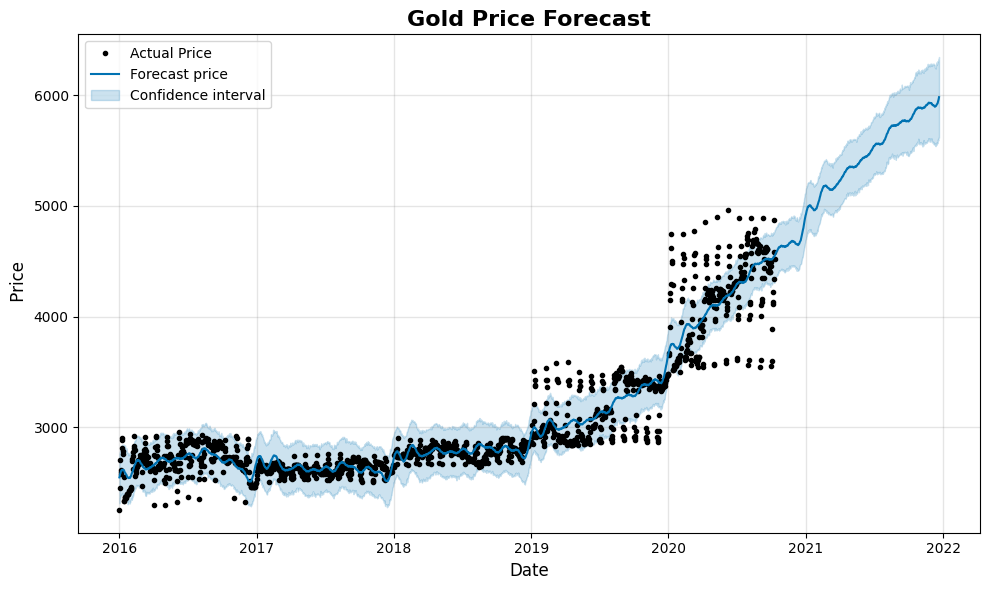

In [ ]:
fig = model_prophet.plot(forecast)
plt.title("Gold Price Forecast", fontsize=16, weight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel(" Price", fontsize=12)
plt.grid(True)
plt.legend(["Actual Price","Forecast price","Confidence interval"], loc="upper left")
plt.tight_layout()
plt.show()


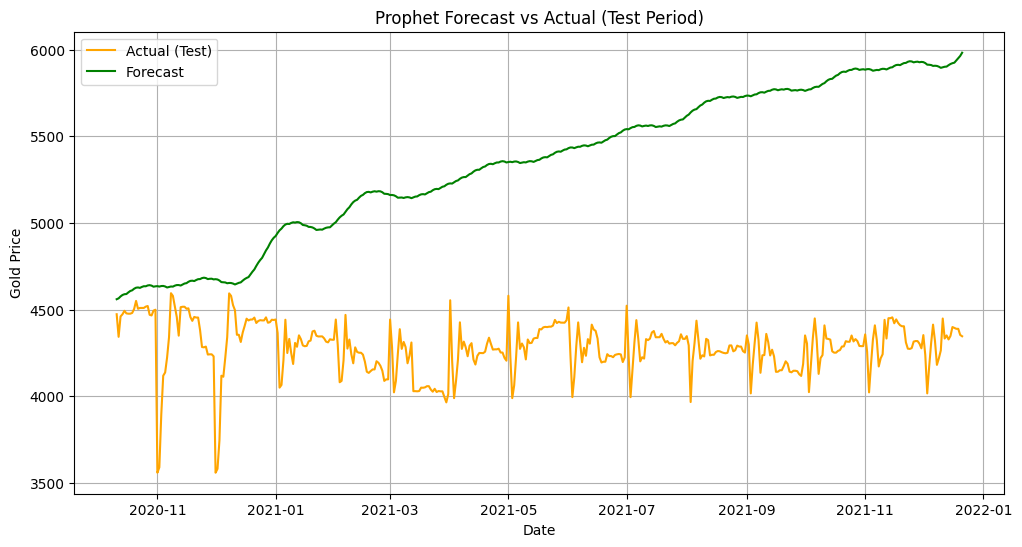

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual (Test)', color='orange')
plt.plot(forecast_only_test['ds'], forecast_only_test['yhat'], label='Forecast', color='green')
plt.title('Prophet Forecast vs Actual (Test Period)')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()

**bold text**
In forecast model buliding for gold price prediction, I Have tried 3 models

Prediction Accuracy (next 30 days):

Linear Regression:r2 is 78%

ARIMA=95-86%

Prophet(meta)=64.78%

best is ARIMA=95.86%